In [ ]:
import yfinance as yf
import pandas as pd


In [ ]:

ticker = 'AAPL'
start_date = '2010-01-01'
end_date = '2023-12-31'


df = yf.download(ticker, start=start_date, end=end_date)

print(f"Downloaded {len(df)} rows of data for {ticker} from {start_date} to {end_date}")


/tmp/ipykernel_733/3640412128.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Downloaded 3522 rows of data for AAPL from 2010-01-01 to 2023-12-31


In [ ]:

display(df.head())

print(df.info())


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
2010-01-05,6.423470,6.459725,6.389611,6.430062,601904800
2010-01-06,6.321296,6.448939,6.314704,6.423470,552160000
2010-01-07,6.309608,6.352156,6.263765,6.344666,477131200
2010-01-08,6.351558,6.352157,6.264067,6.301220,447610800


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   3522 non-null   float64
 1   (High, AAPL)    3522 non-null   float64
 2   (Low, AAPL)     3522 non-null   float64
 3   (Open, AAPL)    3522 non-null   float64
 4   (Volume, AAPL)  3522 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 165.1 KB
None


In [ ]:

from sklearn.preprocessing import MinMaxScaler
import numpy as np


if isinstance(df.columns, pd.MultiIndex):

    close_cols = [col for col in df.columns if 'Close' in col[0]]
    if close_cols:
        data = df[close_cols[0]].values.reshape(-1, 1)
    else:

        print("Warning: 'Close' column not found in multi-index as expected. Attempting to find single 'Close' column.")
        data = df['Close'].values.reshape(-1, 1)
else:

    data = df['Close'].values.reshape(-1, 1)

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original data shape: {data.shape}")
print(f"Scaled data shape: {scaled_data.shape}")

Original data shape: (3522, 1)
Scaled data shape: (3522, 1)


In [ ]:
# Define the training and testing data split
training_data_len = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len - 60:, :]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

Training data length: 2817
Testing data length: 765


In [ ]:

def create_sequences(data, look_back=60):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


look_back = 60


X_train, y_train = create_sequences(train_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)

# Reshape data for RNN (samples, time_steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2757, 60, 1), y_train shape: (2757,)
X_test shape: (705, 60, 1), y_test shape: (705,)


## 2. Model Building

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Model Training


Epoch 1/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - loss: 0.0024
Epoch 2/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 5.7212e-04
Epoch 3/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 6.0021e-04
Epoch 4/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 5.5014e-04
Epoch 5/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 5.2922e-04
Epoch 6/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 4.1458e-04
Epoch 7/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 4.4732e-04
Epoch 8/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - loss: 4.2209e-04
Epoch 9/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 4.6173e-04
Epoch 10/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 4.8841e-04
Epoch 11/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 4.2860e-04
Epoch 12/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 4.4784e-04
Epoch 13/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 3.7985e-04
Epoch 14/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - loss: 3.6257e-04
Epoch 15/25

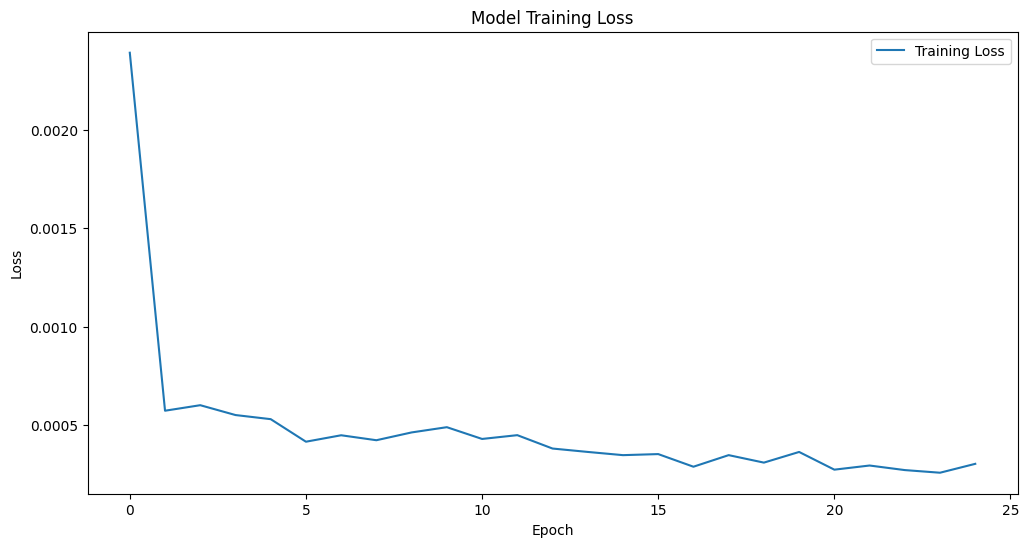

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32)

import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_inverse, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Root Mean Squared Error (RMSE): 6.309999994653919


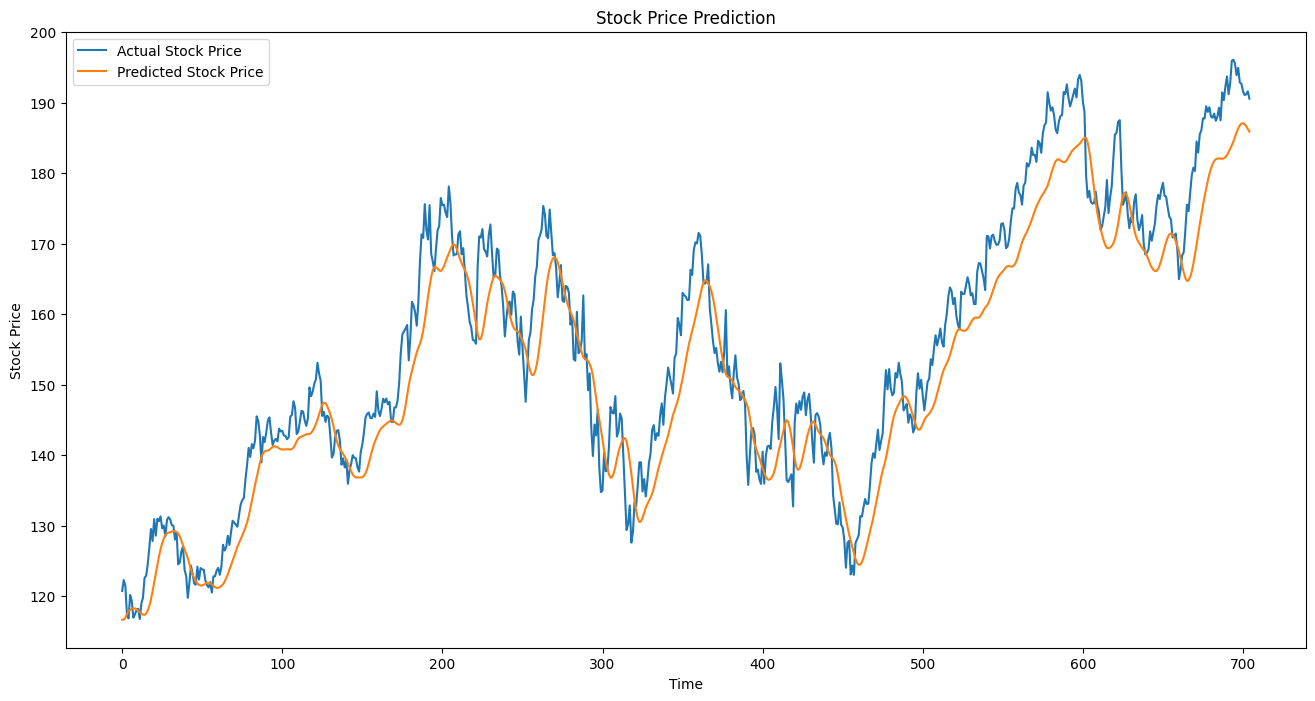

In [ ]:
import matplotlib.pyplot as plt

# Plot the results
plt.figure(figsize=(16, 8))
plt.plot(y_test_inverse, label='Actual Stock Price')
plt.plot(predictions, label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()